###  Goal: Get baseline performance of logistic regression

In [38]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [39]:
import sklearn
print(sklearn.__version__)

1.9.0


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

In [41]:
df = pd.read_csv('../data/cme_dataset.csv', parse_dates=['cme_time'])

In [42]:
df.head(5)

,cme_time,cme_speed_kms,cme_half_angle_deg,cme_latitude,cme_longitude,cme_type_num,cme_id,flare_class,flare_class_num,flare_log_peak_flux,...,wind_density_mean,wind_pressure_mean,wind_efield_mean,wind_temp_mean,ctx_f107,ctx_sunspots,kp_max_post,storm,storm_attributed,storm_attributed_v2
0,2017-02-10 13:48:00,594.0,10.0,18.0,148.0,2.0,0,NaN,NaN,NaN,...,5.500000,2.005278,0.243889,70931.944444,72.027778,22.555556,2.3,0,0,0
1,2017-02-11 06:00:00,456.0,18.0,-1.0,93.0,1.0,1,NaN,NaN,NaN,...,4.745946,1.616486,0.265946,56423.216216,72.972973,23.486486,2.3,0,0,0
2,2017-02-15 03:09:00,405.0,12.0,16.0,-173.0,1.0,2,NaN,NaN,NaN,...,12.597222,2.053611,0.010000,18074.472222,72.833333,19.555556,4.3,0,0,0
3,2017-02-18 02:30:00,239.0,17.0,26.0,-110.0,1.0,3,B,1.0,-6.885685,...,6.983333,3.387500,0.509722,149947.583333,73.675000,13.583333,3.7,0,0,0
4,2017-02-18 07:24:00,492.0,27.0,4.0,88.0,1.0,4,NaN,NaN,NaN,...,6.444444,3.187778,0.266111,137876.500000,73.966667,13.444444,3.7,0,0,0


In [43]:
# feature columns
features = df.drop(columns=['cme_time', 'cme_id', 'flare_class', 'kp_max_post', 'storm_attributed', 'storm_attributed_v2', 'storm'])
print(features.columns)

Index(['cme_speed_kms', 'cme_half_angle_deg', 'cme_latitude', 'cme_longitude',
       'cme_type_num', 'flare_class_num', 'flare_log_peak_flux',
       'flare_duration_min', 'flare_end_time_imputed', 'has_flare',
       'wind_bz_mean', 'wind_bz_min', 'wind_bz_south_frac',
       'wind_bz_strong_south_frac', 'wind_imf_mean', 'wind_speed_mean',
       'wind_speed_max', 'wind_density_mean', 'wind_pressure_mean',
       'wind_efield_mean', 'wind_temp_mean', 'ctx_f107', 'ctx_sunspots'],
      dtype='str')


In [44]:
# target columns
target = df['storm']
print(target)

0       0
1       0
2       0
3       0
4       0
       ..
4729    0
4730    0
4731    0
4732    0
4733    0
Name: storm, Length: 4734, dtype: int64


In [45]:
FEATURE_COLS = [
    'cme_speed_kms', 'cme_half_angle_deg', 'cme_latitude', 'cme_longitude', 'cme_type_num',
    'flare_class_num', 'flare_log_peak_flux', 'flare_duration_min', 'flare_end_time_imputed', 'has_flare',
    'wind_bz_mean', 'wind_bz_min', 'wind_bz_south_frac', 'wind_bz_strong_south_frac',
    'wind_imf_mean', 'wind_speed_mean', 'wind_speed_max',
    'wind_density_mean', 'wind_pressure_mean', 'wind_efield_mean', 'wind_temp_mean',
    'ctx_f107', 'ctx_sunspots',
]

test_filter = df['cme_time'] >= '2023-01-01'
train_filter = df['cme_time'] < '2023-01-01'
X_train = df[train_filter][FEATURE_COLS]
y_train = df[train_filter]['storm']
X_test = df[test_filter][FEATURE_COLS]
y_test = df[test_filter]['storm']

In [46]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['cme_speed_kms','cme_half_angle_deg','cme_latitude',...,'wind_temp_mean', 'ctx_f107','ctx_sunspots']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missi

In [47]:
y_pred      = pipe.predict(X_test)
y_pred_prob = pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc  = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test.mean():.3f})")
print()
print(classification_report(y_test, y_pred, target_names=['No storm', 'Storm']))

ROC-AUC : 0.553
PR-AUC  : 0.336  (no-skill baseline = 0.260)

              precision    recall  f1-score   support

    No storm       0.76      0.24      0.37      2031
       Storm       0.27      0.78      0.40       715

    accuracy                           0.38      2746
   macro avg       0.51      0.51      0.38      2746
weighted avg       0.63      0.38      0.37      2746



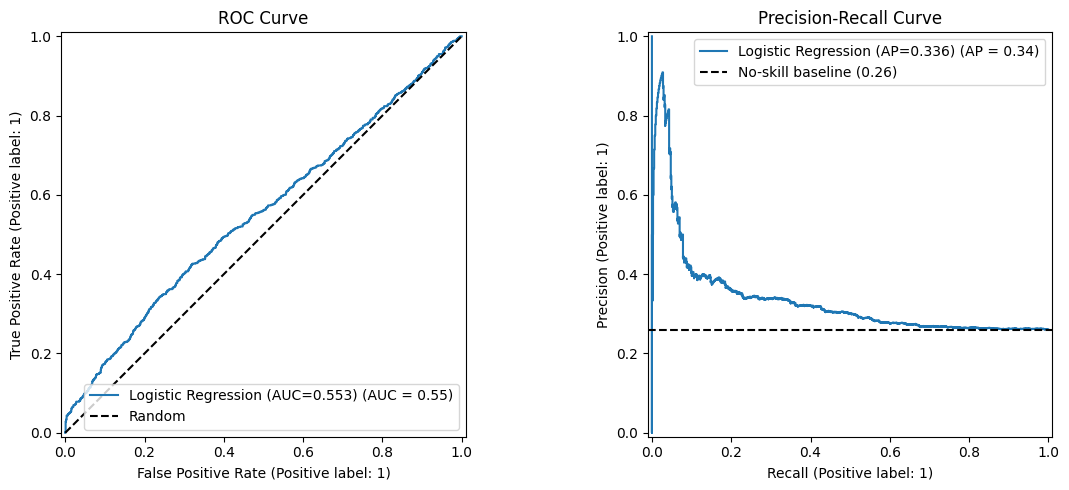

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f'Logistic Regression (AUC={roc_auc:.3f})',
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f'Logistic Regression (AP={pr_auc:.3f})',
    ax=axes[1],
)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label=f'No-skill baseline ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

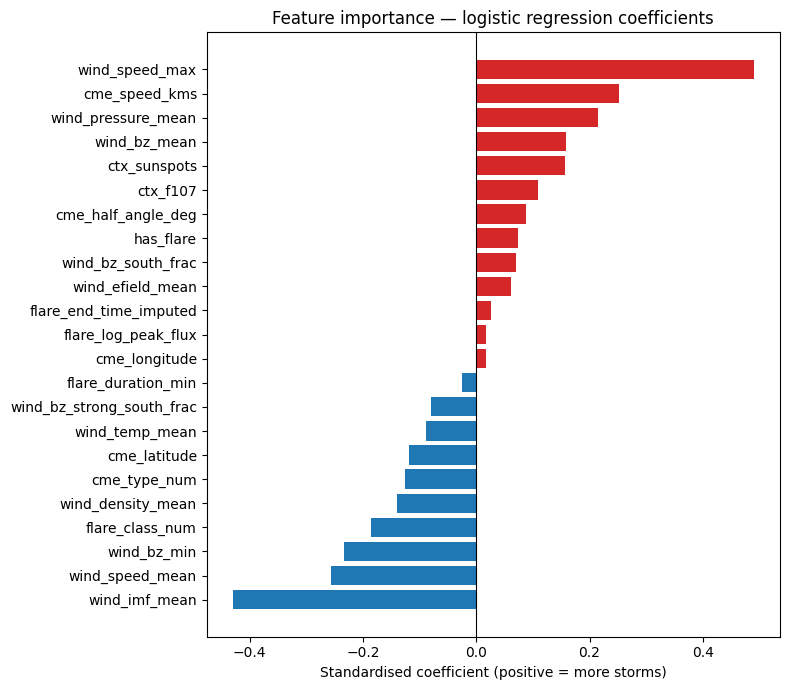


Top positive (storm-associated):
wind_speed_max        0.490167
cme_speed_kms         0.252595
wind_pressure_mean    0.215599
wind_bz_mean          0.159190
ctx_sunspots          0.156157

Top negative (storm-suppressing):
wind_imf_mean       -0.429627
wind_speed_mean     -0.255415
wind_bz_min         -0.233716
flare_class_num     -0.185311
wind_density_mean   -0.139777


In [49]:
coefs = pd.Series(
    pipe.named_steps['clf'].coef_[0],
    index=FEATURE_COLS,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient (positive = more storms)')
ax.set_title('Feature importance — logistic regression coefficients')
plt.tight_layout()
plt.show()

print("\nTop positive (storm-associated):")
print(coefs.tail(5).iloc[::-1].to_string())
print("\nTop negative (storm-suppressing):")
print(coefs.head(5).to_string())

- Precision — of all the CMEs the model predicted would cause a storm, what fraction actually did? High precision = few false alarms.
- Recall — of all the CMEs that actually caused a storm, what fraction did the model catch? High recall = few missed storms.
- F1 score — the harmonic mean of precision and recall. A single number that balances both. Useful when you care about both false alarms and missed storms.
- Support — just the count of actual examples in each class in the test set. Tells you how many "no storm" and "storm" rows the metrics are based on.
- ROC-AUC — measures how well the model ranks storm CMEs above non-storm ones across all possible thresholds. 0.5 = random, 1.0 = perfect. Doesn't care about the actual threshold you pick.
- PR-AUC (average precision) — same idea but on the precision-recall curve. More informative than ROC-AUC when the classes are imbalanced (22% storms), because it focuses on how well the model finds the rare positive class. The no-skill baseline is just the storm rate — e.g. if storms are 22% of the data, a random model scores 0.22.
- ROC curve — plots true positive rate (recall) vs false positive rate at every possible threshold. The further the curve bows toward the top-left corner, the better.
- Precision-Recall curve — plots precision vs recall at every threshold. Better diagnostic for imbalanced data. You want the curve to stay high (top-right). The flat dashed line is the no-skill baseline.
- Feature coefficients (importance) — logistic regression learns one coefficient per feature. Because you scaled all features with StandardScaler first, each coefficient is in the same units (standard deviations), so they're directly comparable in size. A large positive coefficient means "when this feature is high, the model thinks a storm is more likely." A large negative coefficient means the opposite. The features at the extremes of the bar chart are the ones most strongly associated with storm occurrence.